EMG Gesture Classification Pipeline
=====================================

In [ ]:
import sys
sys.path.append('/kaggle/input/python-module')


In [ ]:
!pip install mantis-tsfm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.8/434.8 kB 22.2 MB/s eta 0:00:00
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.7.0
    Uninstalling safetensors-0.7.0:
      Successfully uninstalled safetensors-0.7.0


In [ ]:
import os
import copy
import itertools
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from collections import Counter
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


## Functions

In [4]:
def _to_list(value):
    """Accept a scalar or list and always return a list."""
    return list(value) if isinstance(value, (list, tuple, np.ndarray)) else [value]
 
 
def Data_separation(filename, end_point, segment_length, initializer=True):
    """Load a TSV EMG file and return per-gesture slices (classes 1-6)."""
    Data = pd.read_csv(filename, sep="\t").drop(columns="time")
    cut_point   = end_point
    start_point = 0 if initializer else cut_point - segment_length
    return [
        Data[Data['class'] == cls].iloc[start_point:cut_point]
        for cls in range(1, 7)
    ]
 
 
def load_data(filenames, end_point, segment_length, initializer=True):
    """Load and concatenate gesture data from multiple files."""
    gesture_lists = [[] for _ in range(6)]
    for file in filenames:
        for i, df in enumerate(
            Data_separation(file, end_point, segment_length, initializer=initializer)
        ):
            gesture_lists[i].append(df)
    gestures = [pd.concat(lst, ignore_index=True) for lst in gesture_lists]
    return pd.concat(gestures, ignore_index=True)
 
 
def extract_segments_from_dataframe(data, segment_length=512, step_size=200):
    """Slide a window and extract fixed-length labelled segments."""
    data    = pd.DataFrame(data)
    signals = data.iloc[:, :-1].values
    labels  = data.iloc[:, -1].values.astype(int)
 
    segments, segment_labels = [], []
    for start in range(0, len(signals) - segment_length + 1, step_size):
        end = start + segment_length
        segments.append(signals[start:end, :])
        segment_labels.append(Counter(labels[start:end]).most_common(1)[0][0])
 
    segments       = np.array(segments)
    segment_labels = np.array(segment_labels) - 1   # zero-index
    return segments, segment_labels
 
 
def resize_to_512(X):
    """Linearly interpolate each segment's time axis to length 512."""
    X_tensor = torch.tensor(X, dtype=torch.float)
    X_scaled = F.interpolate(X_tensor, size=512, mode='linear', align_corners=False)
    return X_scaled.numpy()
 
 
 
# ─────────────────────────────────────────────────────────────────────────────
# Main pipeline
# ─────────────────────────────────────────────────────────────────────────────
 
def run_pipeline(
    data_dir:       str        = None,
    raw_data                   = None,
    test_size                  = 0.2,
    tuning_type:    str        = "head",
    segment_length             = 512,
    overlap                    = 0,
    learning_rate              = 2e-4,
    num_epochs                 = 100,
    random_state:   int        = 42,
) -> dict:
    """
    End-to-end EMG gesture classification pipeline using Mantis-8M.
 
    Input modes (exactly one must be provided)
    -------------------------------------------
    data_dir : str, optional
        Root directory walked to find all `.txt` TSV files.
        The pipeline will handle file discovery, loading, and preprocessing.
    raw_data : DataFrame or ndarray, optional
        Already-loaded data where the last column is the class label (1-indexed).
        Steps 1 & 2 (discovery + loading) are skipped entirely; the data goes
        straight into segmentation.
 
    Parameters
    ----------
    test_size : float or list[float]
        Test fraction(s), e.g. 0.2 or [0.2, 0.3, 0.4, 0.5].
    tuning_type : str
        Fine-tuning strategy: ``'head'`` or ``'full'``.
    segment_length : int or list[int]
        Number of samples per sliding-window segment, e.g. 512 or [256, 512].
    overlap : int or list[int]
        Number of samples shared between consecutive windows.
        overlap=0 means no overlap; step equals segment_length.
        overlap=segment_length-1 is maximum overlap (step=1).
        Converted internally via: step_size = segment_length - overlap.
    learning_rate : float or list[float]
        AdamW learning rate(s), e.g. 2e-4 or [1e-4, 2e-4, 5e-4].
    num_epochs : int or list[int]
        Number of training epochs per run, e.g. 100 or [50, 100, 200].
    random_state : int
        Seed for reproducibility.
 
    Returns
    -------
    dict
        ``accuracy_summary`` – dict keyed by (test_size, seg_len, overlap, lr, epochs) → accuracy.
        ``all_results``      – same keys → full result dict per run.
        ``best``             – combo with highest accuracy.
        ``worst``            – combo with lowest accuracy.
        ``mean_accuracy``    – float, mean across all combos.
    """
 
    # ── Guard: exactly one input mode must be used ────────────────────────────
    if data_dir is None and raw_data is None:
        raise ValueError("Provide either 'data_dir' (path) or 'raw_data' (DataFrame/array).")
    if data_dir is not None and raw_data is not None:
        raise ValueError("Provide either 'data_dir' or 'raw_data', not both.")
 
    # Normalise inputs to lists
    test_sizes      = [round(ts, 4) for ts in _to_list(test_size)]
    segment_lengths = _to_list(segment_length)
    overlaps        = _to_list(overlap)
    learning_rates  = _to_list(learning_rate)
    epoch_counts    = _to_list(num_epochs)
 
    # Validate: overlap must be < segment_length for every combination
    for seg_len in segment_lengths:
        for ovlp in overlaps:
            if ovlp >= seg_len:
                raise ValueError(
                    f"overlap={ovlp} must be less than segment_length={seg_len}. "
                    f"Maximum allowed overlap is segment_length-1 = {seg_len - 1}."
                )
 
    n_combos = (len(test_sizes) * len(segment_lengths) * len(overlaps)
                * len(learning_rates) * len(epoch_counts))
    multi    = n_combos > 1
 
    # ── STEP 1 & 2: Obtain raw data ───────────────────────────────────────────
    print("=" * 65)
    if raw_data is not None:
        # ── Mode B: data provided directly — skip loading entirely ────────────
        print("STEP 1 & 2: Using provided raw_data  [file loading skipped]")
        raw_data = pd.DataFrame(raw_data)
        print(f"  raw_data shape: {raw_data.shape}")
    else:
        # ── Mode A: load from directory ───────────────────────────────────────
        print("STEP 1: Discovering data files")
        filenames = [
            os.path.join(root, f)
            for root, _, files in os.walk(data_dir)
            for f in files if f.endswith(".txt")
        ]
        print(f"  Found {len(filenames)} file(s) in '{data_dir}'")
 
        print("\nSTEP 2: Loading raw data  [done once]")
        raw_data = load_data(filenames, end_point=2000, segment_length=2000,
                             initializer=True)
        print(f"  Raw data shape: {raw_data.shape}")
 
    # ── STEP 3: Load pretrained model — done ONCE ────────────────────────────
    print("\nSTEP 3: Loading pretrained Mantis-8M  [done once]")
    from mantis.architecture import Mantis8M
    from mantis.trainer import MantisTrainer
 
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"  Device: {device}")
    base_network = Mantis8M(device=device).from_pretrained("paris-noah/Mantis-8M")
 
    # ── Segmentation cache: recompute only when (segment_length, overlap) changes
    seg_cache = {}
 
    def _get_segments(seg_len, ovlp):
        key = (seg_len, ovlp)
        if key in seg_cache:
            print(f"  [Cache hit]  segment_length={seg_len}, overlap={ovlp} — reusing segments")
            return seg_cache[key]
 
        if 0 < overlap < 1:
            step_size = int(seg_len * overlap)
        else:
            step_size = seg_len - ovlp   # core conversion: overlap → step
        print(f"Step size: {step_size}")
        
        print(f"\n  [Segmenting] segment_length={seg_len}, overlap={ovlp} → step_size={step_size}")
        
        processed = []
        for _, group in raw_data.groupby('class'):
            grp       = group.copy()
            # remainder = len(grp) % seg_len
            # if remainder:
            #     grp = grp[:-remainder]
            processed.append(grp)
        aligned = pd.concat(processed, ignore_index=True).values
 
        X, y = extract_segments_from_dataframe(aligned,
                                               segment_length=seg_len,
                                               step_size=step_size)
        X = X.transpose(0, 2, 1)   # (N, channels, time)
        X = resize_to_512(X)
        print(f"  Segments: {X.shape}  Labels: {y.shape}")
        seg_cache[key] = (X, y)
        return X, y
 
    # ── STEP 4: Sweep all combos ──────────────────────────────────────────────
    accuracy_summary = {}   # (test_size, seg_len, overlap, lr, epochs) → accuracy
    all_results      = {}
 
    combos = list(itertools.product(segment_lengths, overlaps, test_sizes, learning_rates, epoch_counts))
 
    for run_idx, (seg_len, ovlp, ts, lr, epochs) in enumerate(combos, 1):
        combo_key = (ts, seg_len, ovlp, lr, epochs)
 
        print(f"\n{'#' * 65}")
        print(f"# Run {run_idx}/{len(combos)} │ test_size={ts}  seg_len={seg_len}  "
              f"overlap={ovlp}  lr={lr:.2e}  epochs={epochs}")
        print(f"{'#' * 65}")
 
        # Segmentation (pulled from cache if already computed)
        X_full, y_full = _get_segments(seg_len, ovlp)
 
        # Train / test split
        X_train, X_test, y_train, y_test = train_test_split(
            X_full, y_full,
            test_size=ts,
            random_state=random_state,
            stratify=y_full,
        )
        print(f"  Split → Train: {X_train.shape}  Test: {X_test.shape}")
 
        # Deep-copy pretrained weights so each run starts from scratch
        network = copy.deepcopy(base_network)
        model   = MantisTrainer(device=device, network=network)
 
        def make_optimizer(lr_val):
            def init_optimizer(params):
                return torch.optim.AdamW(
                    params, lr=lr_val, betas=(0.9, 0.999), weight_decay=0.05
                )
            return init_optimizer
 
        print(f"  Fine-tuning  type='{tuning_type}'  epochs={epochs}  lr={lr:.2e}")
        model.fit(
            X_train, y_train,
            num_epochs=epochs,
            fine_tuning_type=tuning_type,
            init_optimizer=make_optimizer(lr),
        )
 
        y_pred   = model.predict(X_test)
        accuracy = float(np.mean(y_test == y_pred))
        print(f"  ✓ Accuracy: {accuracy:.4f}")
 
        accuracy_summary[combo_key] = accuracy
        all_results[combo_key] = {
            "accuracy": accuracy,
            "y_test":   y_test,
            "y_pred":   y_pred,
            "X_train":  X_train,
            "X_test":   X_test,
            "model":    model,
        }
 
    # ── Summary ───────────────────────────────────────────────────────────────
    best_key  = max(accuracy_summary, key=accuracy_summary.get)
    worst_key = min(accuracy_summary, key=accuracy_summary.get)
    mean_acc  = float(np.mean(list(accuracy_summary.values())))
 
    print("\n" + "=" * 65)
    print("ACCURACY SUMMARY")
    print("=" * 65)
    if multi:
        print(f"  {'test_size':>10}  {'seg_len':>8}  {'overlap':>8}  {'lr':>10}  {'epochs':>7}  {'accuracy':>10}")
        print("  " + "-" * 62)
        for (ts, seg_len, ovlp, lr, epochs), acc in accuracy_summary.items():
            print(f"  {ts:>10.2f}  {seg_len:>8}  {ovlp:>8}  {lr:>10.2e}  {epochs:>7}  {acc:>10.4f}")
        print("  " + "-" * 62)
        print(f"  Mean accuracy : {mean_acc:.4f}")
        print(f"  Best  combo   : test_size={best_key[0]}  seg_len={best_key[1]}  "
              f"overlap={best_key[2]}  lr={best_key[3]:.2e}  epochs={best_key[4]}  "
              f"→ {accuracy_summary[best_key]:.4f}")
        print(f"  Worst combo   : test_size={worst_key[0]}  seg_len={worst_key[1]}  "
              f"overlap={worst_key[2]}  lr={worst_key[3]:.2e}  epochs={worst_key[4]}  "
              f"→ {accuracy_summary[worst_key]:.4f}")
    else:
        ts, seg_len, ovlp, lr, epochs = best_key
        print(f"  test_size={ts}  seg_len={seg_len}  overlap={ovlp}  lr={lr:.2e}  "
              f"epochs={epochs}  accuracy={accuracy_summary[best_key]:.4f}")
    print("=" * 65)
 
    return {
        "accuracy_summary": accuracy_summary,
        "all_results":      all_results,
        "best":             {"combo": best_key,  "accuracy": accuracy_summary[best_key]},
        "worst":            {"combo": worst_key, "accuracy": accuracy_summary[worst_key]},
        "mean_accuracy":    mean_acc,
    }
 
 

# Example usage
## ────────────────────────────────────────────────────────────

In [ ]:
# seed = 42
seedList = [1, 5, 42, 100, 123] 


STEP 1: Discovering data files
  Found 72 file(s) in '/kaggle/input/datasets/rifattanbhir/emg-dataset'

STEP 2: Loading raw data  [done once]
  Raw data shape: (864000, 9)

STEP 3: Loading pretrained Mantis-8M  [done once]
  Device: cuda


config.json:   0%|          | 0.00/335 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/32.5M [00:00<?, ?B/s]


#################################################################
# Run 1/50 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=5
#################################################################
Step size: 256

  [Segmenting] segment_length=512, overlap=256 → step_size=256
  Segments: (3374, 8, 512)  Labels: (3374,)
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='head'  epochs=5  lr=2.00e-04


Epoch 4: Train Loss 1.4865: 100%|██████████| 5/5 [00:00<00:00, 14.28it/s]


...

  ✓ Accuracy: 0.8385

#################################################################
# Run 49/50 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=245
#################################################################
  [Cache hit]  segment_length=512, overlap=256 — reusing segments
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='head'  epochs=245  lr=2.00e-04


Epoch 244: Train Loss 0.1281: 100%|██████████| 245/245 [00:09<00:00, 26.47it/s]


  ✓ Accuracy: 0.8385

#################################################################
# Run 50/50 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=250
#################################################################
  [Cache hit]  segment_length=512, overlap=256 — reusing segments
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='head'  epochs=250  lr=2.00e-04


Epoch 249: Train Loss 0.1274: 100%|██████████| 250/250 [00:09<00:00, 25.89it/s]


  ✓ Accuracy: 0.8430

ACCURACY SUMMARY
   test_size   seg_len   overlap          lr   epochs    accuracy
  --------------------------------------------------------------
        0.20       512       256    2.00e-04        5      0.5511
        0.20       512       256    2.00e-04       10      0.7837
        0.20       512       256    2.00e-04       15      0.8044
        0.20       512       256    2.00e-04       20      0.8311
        0.20       512       256    2.00e-04       25      0.8341
        0.20       512       256    2.00e-04       30      0.8252
        0.20       512       256    2.00e-04       35      0.8400
        0.20       512       256    2.00e-04       40      0.8311
        0.20       512       256    2.00e-04       45      0.8415
        0.20       512       256    2.00e-04       50      0.8326
        0.20       512       256    2.00e-04       55      0.8430
        0.20       512       256    2.00e-04       60      0.8341
        0.20       512       256    2.

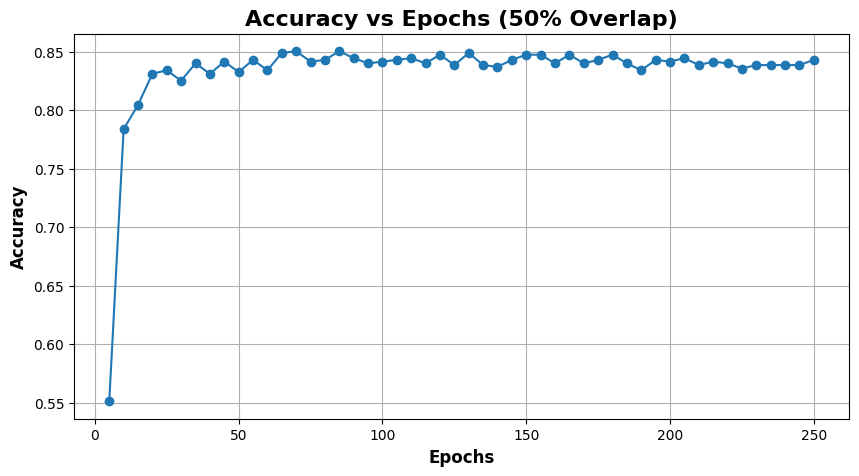

STEP 1: Discovering data files
  Found 72 file(s) in '/kaggle/input/datasets/rifattanbhir/emg-dataset'

STEP 2: Loading raw data  [done once]
  Raw data shape: (864000, 9)

STEP 3: Loading pretrained Mantis-8M  [done once]
  Device: cuda

#################################################################
# Run 1/50 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=5
#################################################################
Step size: 256

  [Segmenting] segment_length=512, overlap=256 → step_size=256
  Segments: (3374, 8, 512)  Labels: (3374,)
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='head'  epochs=5  lr=2.00e-04


Epoch 4: Train Loss 1.4133: 100%|██████████| 5/5 [00:00<00:00, 26.47it/s]


  ✓ Accuracy: 0.5526

#################################################################
# Run 2/50 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=10
#################################################################
  [Cache hit]  segment_length=512, overlap=256 — reusing segments
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='head'  epochs=10  lr=2.00e-04


Epoch 9: Train Loss 0.7990: 100%|██████████| 10/10 [00:00<00:00, 26.97it/s]


  ✓ Accuracy: 0.7956

#################################################################
# Run 3/50 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=15
#################################################################
  [Cache hit]  segment_length=512, overlap=256 — reusing segments
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='head'  epochs=15  lr=2.00e-04


...

  ✓ Accuracy: 0.8444

#################################################################
# Run 49/50 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=245
#################################################################
  [Cache hit]  segment_length=512, overlap=256 — reusing segments
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='head'  epochs=245  lr=2.00e-04


Epoch 244: Train Loss 0.1332: 100%|██████████| 245/245 [00:09<00:00, 26.64it/s]


  ✓ Accuracy: 0.8415

#################################################################
# Run 50/50 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=250
#################################################################
  [Cache hit]  segment_length=512, overlap=256 — reusing segments
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='head'  epochs=250  lr=2.00e-04


Epoch 249: Train Loss 0.1210: 100%|██████████| 250/250 [00:09<00:00, 25.65it/s]


  ✓ Accuracy: 0.8400

ACCURACY SUMMARY
   test_size   seg_len   overlap          lr   epochs    accuracy
  --------------------------------------------------------------
        0.20       512       256    2.00e-04        5      0.5526
        0.20       512       256    2.00e-04       10      0.7956
        0.20       512       256    2.00e-04       15      0.8311
        0.20       512       256    2.00e-04       20      0.8370
        0.20       512       256    2.00e-04       25      0.8207
        0.20       512       256    2.00e-04       30      0.8385
        0.20       512       256    2.00e-04       35      0.8267
        0.20       512       256    2.00e-04       40      0.8281
        0.20       512       256    2.00e-04       45      0.8341
        0.20       512       256    2.00e-04       50      0.8341
        0.20       512       256    2.00e-04       55      0.8415
        0.20       512       256    2.00e-04       60      0.8370
        0.20       512       256    2.

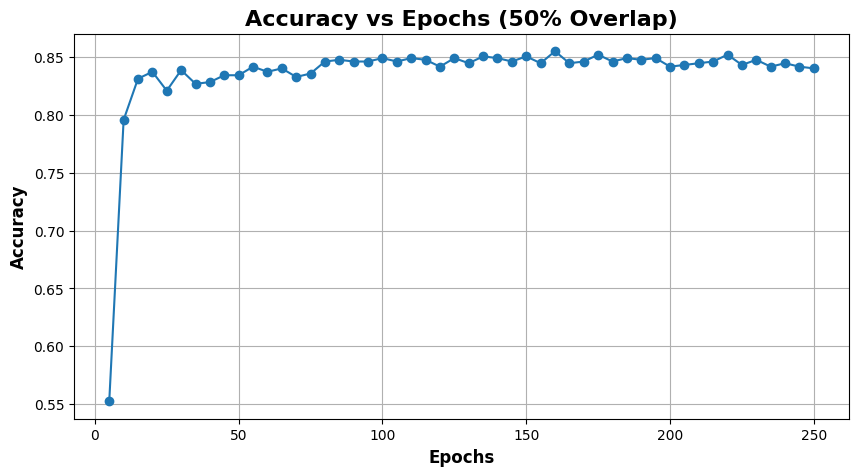

STEP 1: Discovering data files
  Found 72 file(s) in '/kaggle/input/datasets/rifattanbhir/emg-dataset'

STEP 2: Loading raw data  [done once]
  Raw data shape: (864000, 9)

STEP 3: Loading pretrained Mantis-8M  [done once]
  Device: cuda

#################################################################
# Run 1/50 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=5
#################################################################
Step size: 256

  [Segmenting] segment_length=512, overlap=256 → step_size=256
  Segments: (3374, 8, 512)  Labels: (3374,)
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='head'  epochs=5  lr=2.00e-04


Epoch 4: Train Loss 1.4039: 100%|██████████| 5/5 [00:00<00:00, 26.42it/s]


  ✓ Accuracy: 0.6296

#################################################################
# Run 2/50 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=10
#################################################################
  [Cache hit]  segment_length=512, overlap=256 — reusing segments
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='head'  epochs=10  lr=2.00e-04


Epoch 9: Train Loss 0.8395: 100%|██████████| 10/10 [00:00<00:00, 25.89it/s]


  ✓ Accuracy: 0.7881

#################################################################
# Run 3/50 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=15
#################################################################
  [Cache hit]  segment_length=512, overlap=256 — reusing segments
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='head'  epochs=15  lr=2.00e-04


...

  ✓ Accuracy: 0.8726

#################################################################
# Run 49/50 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=245
#################################################################
  [Cache hit]  segment_length=512, overlap=256 — reusing segments
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='head'  epochs=245  lr=2.00e-04


Epoch 244: Train Loss 0.1339: 100%|██████████| 245/245 [00:09<00:00, 26.47it/s]


  ✓ Accuracy: 0.8607

#################################################################
# Run 50/50 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=250
#################################################################
  [Cache hit]  segment_length=512, overlap=256 — reusing segments
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='head'  epochs=250  lr=2.00e-04


Epoch 249: Train Loss 0.1284: 100%|██████████| 250/250 [00:09<00:00, 26.78it/s]


  ✓ Accuracy: 0.8711

ACCURACY SUMMARY
   test_size   seg_len   overlap          lr   epochs    accuracy
  --------------------------------------------------------------
        0.20       512       256    2.00e-04        5      0.6296
        0.20       512       256    2.00e-04       10      0.7881
        0.20       512       256    2.00e-04       15      0.8207
        0.20       512       256    2.00e-04       20      0.8400
        0.20       512       256    2.00e-04       25      0.8444
        0.20       512       256    2.00e-04       30      0.8519
        0.20       512       256    2.00e-04       35      0.8400
        0.20       512       256    2.00e-04       40      0.8563
        0.20       512       256    2.00e-04       45      0.8504
        0.20       512       256    2.00e-04       50      0.8607
        0.20       512       256    2.00e-04       55      0.8563
        0.20       512       256    2.00e-04       60      0.8563
        0.20       512       256    2.

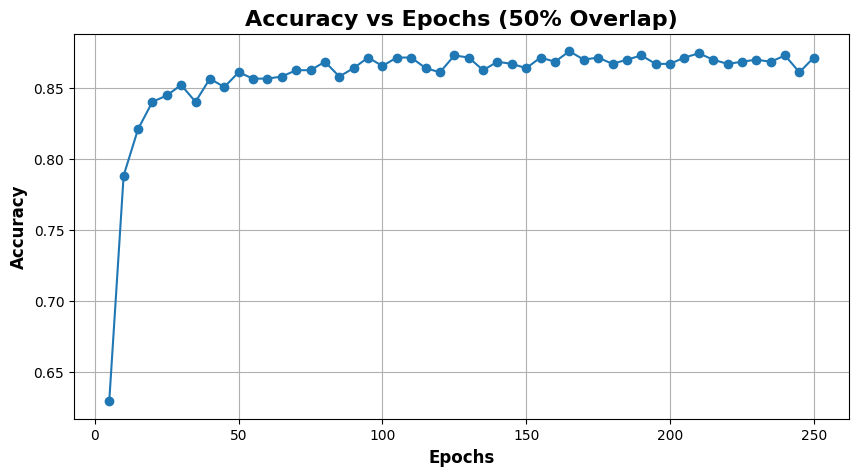

STEP 1: Discovering data files
  Found 72 file(s) in '/kaggle/input/datasets/rifattanbhir/emg-dataset'

STEP 2: Loading raw data  [done once]
  Raw data shape: (864000, 9)

STEP 3: Loading pretrained Mantis-8M  [done once]
  Device: cuda

#################################################################
# Run 1/50 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=5
#################################################################
Step size: 256

  [Segmenting] segment_length=512, overlap=256 → step_size=256
  Segments: (3374, 8, 512)  Labels: (3374,)
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='head'  epochs=5  lr=2.00e-04


Epoch 4: Train Loss 1.4753: 100%|██████████| 5/5 [00:00<00:00, 26.65it/s]


  ✓ Accuracy: 0.5659

#################################################################
# Run 2/50 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=10
#################################################################
  [Cache hit]  segment_length=512, overlap=256 — reusing segments
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='head'  epochs=10  lr=2.00e-04


Epoch 9: Train Loss 0.8328: 100%|██████████| 10/10 [00:00<00:00, 27.07it/s]


  ✓ Accuracy: 0.8000

#################################################################
# Run 3/50 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=15
#################################################################
  [Cache hit]  segment_length=512, overlap=256 — reusing segments
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='head'  epochs=15  lr=2.00e-04


...

  ✓ Accuracy: 0.8622

#################################################################
# Run 49/50 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=245
#################################################################
  [Cache hit]  segment_length=512, overlap=256 — reusing segments
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='head'  epochs=245  lr=2.00e-04


Epoch 244: Train Loss 0.1265: 100%|██████████| 245/245 [00:09<00:00, 26.71it/s]


  ✓ Accuracy: 0.8593

#################################################################
# Run 50/50 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=250
#################################################################
  [Cache hit]  segment_length=512, overlap=256 — reusing segments
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='head'  epochs=250  lr=2.00e-04


Epoch 249: Train Loss 0.1242: 100%|██████████| 250/250 [00:09<00:00, 26.67it/s]


  ✓ Accuracy: 0.8637

ACCURACY SUMMARY
   test_size   seg_len   overlap          lr   epochs    accuracy
  --------------------------------------------------------------
        0.20       512       256    2.00e-04        5      0.5659
        0.20       512       256    2.00e-04       10      0.8000
        0.20       512       256    2.00e-04       15      0.8044
        0.20       512       256    2.00e-04       20      0.8237
        0.20       512       256    2.00e-04       25      0.8296
        0.20       512       256    2.00e-04       30      0.8326
        0.20       512       256    2.00e-04       35      0.8474
        0.20       512       256    2.00e-04       40      0.8444
        0.20       512       256    2.00e-04       45      0.8504
        0.20       512       256    2.00e-04       50      0.8533
        0.20       512       256    2.00e-04       55      0.8489
        0.20       512       256    2.00e-04       60      0.8489
        0.20       512       256    2.

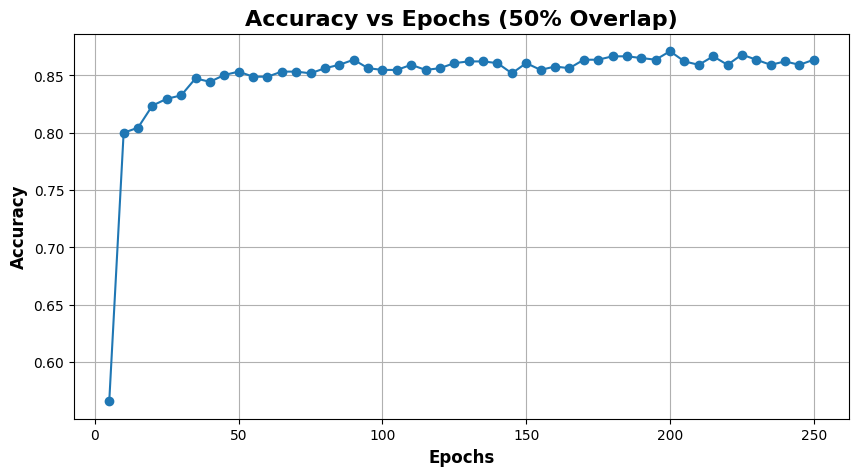

STEP 1: Discovering data files
  Found 72 file(s) in '/kaggle/input/datasets/rifattanbhir/emg-dataset'

STEP 2: Loading raw data  [done once]
  Raw data shape: (864000, 9)

STEP 3: Loading pretrained Mantis-8M  [done once]
  Device: cuda

#################################################################
# Run 1/50 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=5
#################################################################
Step size: 256

  [Segmenting] segment_length=512, overlap=256 → step_size=256
  Segments: (3374, 8, 512)  Labels: (3374,)
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='head'  epochs=5  lr=2.00e-04


Epoch 4: Train Loss 1.4068: 100%|██████████| 5/5 [00:00<00:00, 25.58it/s]


  ✓ Accuracy: 0.5896

#################################################################
# Run 2/50 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=10
#################################################################
  [Cache hit]  segment_length=512, overlap=256 — reusing segments
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='head'  epochs=10  lr=2.00e-04


Epoch 9: Train Loss 0.7982: 100%|██████████| 10/10 [00:00<00:00, 26.57it/s]


  ✓ Accuracy: 0.8193

#################################################################
# Run 3/50 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=15
#################################################################
  [Cache hit]  segment_length=512, overlap=256 — reusing segments
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='head'  epochs=15  lr=2.00e-04


...

  ✓ Accuracy: 0.8489

#################################################################
# Run 49/50 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=245
#################################################################
  [Cache hit]  segment_length=512, overlap=256 — reusing segments
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='head'  epochs=245  lr=2.00e-04


Epoch 244: Train Loss 0.1276: 100%|██████████| 245/245 [00:09<00:00, 25.56it/s]


  ✓ Accuracy: 0.8533

#################################################################
# Run 50/50 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=250
#################################################################
  [Cache hit]  segment_length=512, overlap=256 — reusing segments
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='head'  epochs=250  lr=2.00e-04


Epoch 249: Train Loss 0.1237: 100%|██████████| 250/250 [00:09<00:00, 26.58it/s]


  ✓ Accuracy: 0.8607

ACCURACY SUMMARY
   test_size   seg_len   overlap          lr   epochs    accuracy
  --------------------------------------------------------------
        0.20       512       256    2.00e-04        5      0.5896
        0.20       512       256    2.00e-04       10      0.8193
        0.20       512       256    2.00e-04       15      0.8237
        0.20       512       256    2.00e-04       20      0.8296
        0.20       512       256    2.00e-04       25      0.8459
        0.20       512       256    2.00e-04       30      0.8385
        0.20       512       256    2.00e-04       35      0.8533
        0.20       512       256    2.00e-04       40      0.8504
        0.20       512       256    2.00e-04       45      0.8459
        0.20       512       256    2.00e-04       50      0.8474
        0.20       512       256    2.00e-04       55      0.8519
        0.20       512       256    2.00e-04       60      0.8607
        0.20       512       256    2.

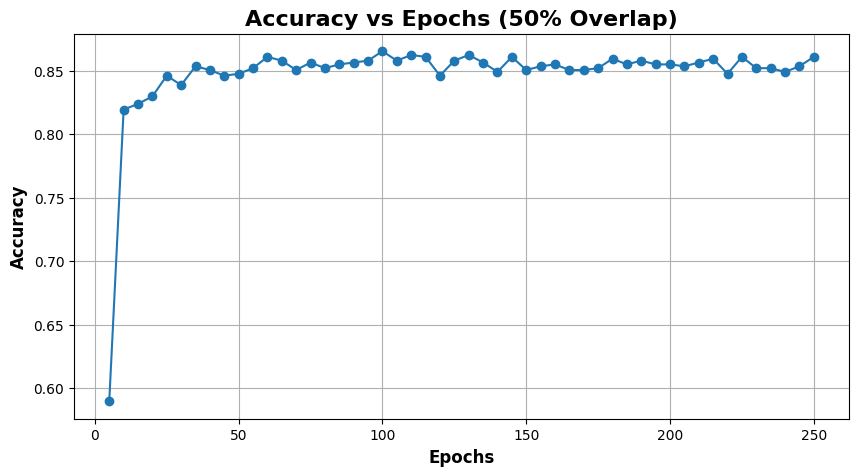

In [ ]:
import matplotlib.pyplot as plt
# if __name__ == "__main__":
# seedList = [1, 5, 42, 100, 123] 
for seed in seedList:
    # ── Single run ──────────────────────────────────────────────────────────
    results = run_pipeline(
        data_dir      = "/kaggle/input/datasets/rifattanbhir/emg-dataset",
        test_size     = 0.2,
        tuning_type   = "head",
        segment_length= 512,
        overlap       = 256,
        learning_rate = 2e-4,
        num_epochs    = list([i*5 for i in range(1, 51)]),
        random_state  = seed,
    )
    epoch_accuracy = [(epochs, acc) for (ts, seg_len, ovlp, lr, epochs), acc in results["accuracy_summary"].items()]

    # Or as two separate lists, useful for plotting
    epoch_list    = [epochs for (_, _, _, _, epochs), _ in results["accuracy_summary"].items()]
    accuracy_list = [acc    for _, acc               in results["accuracy_summary"].items()]
    np.save(f'50%_overlap_accuracy_seed{seed}.npy', accuracy_list)
    np.save(f'50%_overlap_epoch_seed{seed}.npy', epoch_list)
    
    # Plotting
    plt.figure(figsize=(10,5))
    plt.plot(epoch_list, accuracy_list, marker='o')
    plt.grid('True')
    plt.xlabel('Epochs', fontsize=12, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
    plt.title('Accuracy vs Epochs (50% Overlap)', fontsize=16, fontweight='bold')
    plt.savefig('accuracy_plot_50%_overlap.tif', dpi=300)
    plt.show()
    # accuracy_list


In [ ]:
# if __name__ == "__main__":
for seed in seedList:
    print('*-'*30,"\nWith 50% overlapping")
    print('*-'*30)
 
    # ── Single run ──────────────────────────────────────────────────────────
    results = run_pipeline(
        data_dir      = "/kaggle/input/datasets/rifattanbhir/emg-dataset",
        test_size     = [0.2, 0.3, 0.4],
        tuning_type   = "head",
        segment_length= [200, 300, 400, 512],
        overlap       = 0.5,
        learning_rate = 2e-4,
        num_epochs    = 130,
        random_state  = seed,
    )
    
    # Build a DataFrame from accuracy_summary
    rows = []
    for (ts, seg_len, ovlp, lr, epochs), acc in results["accuracy_summary"].items():
        rows.append({
            "test_size": ts,
            "seg_len":   seg_len,
            "overlap":   ovlp,
            "lr":        lr,
            "epochs":    epochs,
            "accuracy":  acc
        })
    
    df = pd.DataFrame(rows)
    
    # Add summary rows
    summary = pd.DataFrame([
        {"test_size": "MEAN",  "accuracy": results["mean_accuracy"]},
        {"test_size": "BEST",  "seg_len": results["best"]["combo"][1],  "accuracy": results["best"]["accuracy"]},
        {"test_size": "WORST", "seg_len": results["worst"]["combo"][1], "accuracy": results["worst"]["accuracy"]},
    ])
    
    df_final = pd.concat([df, summary], ignore_index=True)
    df_final.to_csv(f"'head'_50%_overlap_accuracy_summary_seed{seed}.csv", index=False)


*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*- 
With 50% overlapping
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-
STEP 1: Discovering data files
  Found 72 file(s) in '/kaggle/input/datasets/rifattanbhir/emg-dataset'

STEP 2: Loading raw data  [done once]
  Raw data shape: (864000, 9)

STEP 3: Loading pretrained Mantis-8M  [done once]
  Device: cuda

#################################################################
# Run 1/12 │ test_size=0.2  seg_len=200  overlap=0.5  lr=2.00e-04  epochs=130
#################################################################
Step size: 100

  [Segmenting] segment_length=200, overlap=0.5 → step_size=100
  Segments: (8639, 8, 512)  Labels: (8639,)
  Split → Train: (6911, 8, 512)  Test: (1728, 8, 512)
  Fine-tuning  type='head'  epochs=130  lr=2.00e-04


Epoch 129: Train Loss 0.2568: 100%|██████████| 130/130 [00:12<00:00, 10.45it/s]


  ✓ Accuracy: 0.8524

#################################################################
# Run 2/12 │ test_size=0.3  seg_len=200  overlap=0.5  lr=2.00e-04  epochs=130
#################################################################
  [Cache hit]  segment_length=200, overlap=0.5 — reusing segments
  Split → Train: (6047, 8, 512)  Test: (2592, 8, 512)
  Fine-tuning  type='head'  epochs=130  lr=2.00e-04


Epoch 129: Train Loss 0.2601: 100%|██████████| 130/130 [00:10<00:00, 11.88it/s]


  ✓ Accuracy: 0.8445

#################################################################
# Run 3/12 │ test_size=0.4  seg_len=200  overlap=0.5  lr=2.00e-04  epochs=130
#################################################################
  [Cache hit]  segment_length=200, overlap=0.5 — reusing segments
  Split → Train: (5183, 8, 512)  Test: (3456, 8, 512)
  Fine-tuning  type='head'  epochs=130  lr=2.00e-04


...

  ✓ Accuracy: 0.8563

#################################################################
# Run 11/12 │ test_size=0.3  seg_len=512  overlap=0.5  lr=2.00e-04  epochs=130
#################################################################
  [Cache hit]  segment_length=512, overlap=0.5 — reusing segments
  Split → Train: (2361, 8, 512)  Test: (1013, 8, 512)
  Fine-tuning  type='head'  epochs=130  lr=2.00e-04


Epoch 129: Train Loss 0.2251: 100%|██████████| 130/130 [00:04<00:00, 30.70it/s]


  ✓ Accuracy: 0.8559

#################################################################
# Run 12/12 │ test_size=0.4  seg_len=512  overlap=0.5  lr=2.00e-04  epochs=130
#################################################################
  [Cache hit]  segment_length=512, overlap=0.5 — reusing segments
  Split → Train: (2024, 8, 512)  Test: (1350, 8, 512)
  Fine-tuning  type='head'  epochs=130  lr=2.00e-04


Epoch 129: Train Loss 0.2307: 100%|██████████| 130/130 [00:03<00:00, 34.68it/s]


  ✓ Accuracy: 0.8481

ACCURACY SUMMARY
   test_size   seg_len   overlap          lr   epochs    accuracy
  --------------------------------------------------------------
        0.20       200       0.5    2.00e-04      130      0.8490
        0.30       200       0.5    2.00e-04      130      0.8519
        0.40       200       0.5    2.00e-04      130      0.8455
        0.20       300       0.5    2.00e-04      130      0.8715
        0.30       300       0.5    2.00e-04      130      0.8600
        0.40       300       0.5    2.00e-04      130      0.8529
        0.20       400       0.5    2.00e-04      130      0.8553
        0.30       400       0.5    2.00e-04      130      0.8488
        0.40       400       0.5    2.00e-04      130      0.8501
        0.20       512       0.5    2.00e-04      130      0.8563
        0.30       512       0.5    2.00e-04      130      0.8559
        0.40       512       0.5    2.00e-04      130      0.8481
  ------------------------------------

In [ ]:
# if __name__ == "__main__":
for seed in seedList:
 
    # ── Single run ──────────────────────────────────────────────────────────
    results = run_pipeline(
        data_dir      = "/kaggle/input/datasets/rifattanbhir/emg-dataset",
        test_size     = 0.2,
        tuning_type   = "full",
        segment_length= 512,
        overlap       = 256,
        learning_rate = 2e-4,
        num_epochs    = 130,
        random_state  = seed,
    )

    # Build a DataFrame from accuracy_summary
    rows = []
    for (ts, seg_len, ovlp, lr, epochs), acc in results["accuracy_summary"].items():
        rows.append({
            "test_size": ts,
            "seg_len":   seg_len,
            "overlap":   ovlp,
            "lr":        lr,
            "epochs":    epochs,
            "accuracy":  acc
        })
    
    df = pd.DataFrame(rows)
    
    # Add summary rows
    summary = pd.DataFrame([
        {"test_size": "MEAN",  "accuracy": results["mean_accuracy"]},
        {"test_size": "BEST",  "seg_len": results["best"]["combo"][1],  "accuracy": results["best"]["accuracy"]},
        {"test_size": "WORST", "seg_len": results["worst"]["combo"][1], "accuracy": results["worst"]["accuracy"]},
    ])
    
    df_final = pd.concat([df, summary], ignore_index=True)
    df_final.to_csv(f"'full'_50%_overlap_accuracy_summary_seed{seed}.csv", index=False)


STEP 1: Discovering data files
  Found 72 file(s) in '/kaggle/input/datasets/rifattanbhir/emg-dataset'

STEP 2: Loading raw data  [done once]
  Raw data shape: (864000, 9)

STEP 3: Loading pretrained Mantis-8M  [done once]
  Device: cuda

#################################################################
# Run 1/1 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=130
#################################################################
Step size: 256

  [Segmenting] segment_length=512, overlap=256 → step_size=256
  Segments: (3374, 8, 512)  Labels: (3374,)
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='full'  epochs=130  lr=2.00e-04


Epoch 129: Train Loss 0.0021: 100%|██████████| 130/130 [40:41<00:00, 18.78s/it]


  ✓ Accuracy: 0.9007

ACCURACY SUMMARY
  test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=130  accuracy=0.9007
STEP 1: Discovering data files
  Found 72 file(s) in '/kaggle/input/datasets/rifattanbhir/emg-dataset'

STEP 2: Loading raw data  [done once]
  Raw data shape: (864000, 9)

STEP 3: Loading pretrained Mantis-8M  [done once]
  Device: cuda

#################################################################
# Run 1/1 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=130
#################################################################
Step size: 256

  [Segmenting] segment_length=512, overlap=256 → step_size=256
  Segments: (3374, 8, 512)  Labels: (3374,)
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='full'  epochs=130  lr=2.00e-04


Epoch 129: Train Loss 0.0020: 100%|██████████| 130/130 [40:40<00:00, 18.77s/it]


  ✓ Accuracy: 0.8963

ACCURACY SUMMARY
  test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=130  accuracy=0.8963
STEP 1: Discovering data files
  Found 72 file(s) in '/kaggle/input/datasets/rifattanbhir/emg-dataset'

STEP 2: Loading raw data  [done once]
  Raw data shape: (864000, 9)

STEP 3: Loading pretrained Mantis-8M  [done once]
  Device: cuda

#################################################################
# Run 1/1 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=130
#################################################################
Step size: 256

  [Segmenting] segment_length=512, overlap=256 → step_size=256
  Segments: (3374, 8, 512)  Labels: (3374,)
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='full'  epochs=130  lr=2.00e-04


...

  ✓ Accuracy: 0.9393

ACCURACY SUMMARY
  test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=130  accuracy=0.9393
STEP 1: Discovering data files
  Found 72 file(s) in '/kaggle/input/datasets/rifattanbhir/emg-dataset'

STEP 2: Loading raw data  [done once]
  Raw data shape: (864000, 9)

STEP 3: Loading pretrained Mantis-8M  [done once]
  Device: cuda

#################################################################
# Run 1/1 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=130
#################################################################
Step size: 256

  [Segmenting] segment_length=512, overlap=256 → step_size=256
  Segments: (3374, 8, 512)  Labels: (3374,)
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='full'  epochs=130  lr=2.00e-04


Epoch 129: Train Loss 0.0022: 100%|██████████| 130/130 [40:41<00:00, 18.78s/it]


  ✓ Accuracy: 0.9259

ACCURACY SUMMARY
  test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=130  accuracy=0.9259
STEP 1: Discovering data files
  Found 72 file(s) in '/kaggle/input/datasets/rifattanbhir/emg-dataset'

STEP 2: Loading raw data  [done once]
  Raw data shape: (864000, 9)

STEP 3: Loading pretrained Mantis-8M  [done once]
  Device: cuda

#################################################################
# Run 1/1 │ test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=130
#################################################################
Step size: 256

  [Segmenting] segment_length=512, overlap=256 → step_size=256
  Segments: (3374, 8, 512)  Labels: (3374,)
  Split → Train: (2699, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='full'  epochs=130  lr=2.00e-04


Epoch 129: Train Loss 0.0020: 100%|██████████| 130/130 [40:41<00:00, 18.78s/it]


  ✓ Accuracy: 0.9319

ACCURACY SUMMARY
  test_size=0.2  seg_len=512  overlap=256  lr=2.00e-04  epochs=130  accuracy=0.9319


### Without Overlapping

STEP 1: Discovering data files
  Found 72 file(s) in '/kaggle/input/datasets/rifattanbhir/emg-dataset'

STEP 2: Loading raw data  [done once]
  Raw data shape: (864000, 9)

STEP 3: Loading pretrained Mantis-8M  [done once]
  Device: cuda

#################################################################
# Run 1/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=5
#################################################################
Step size: 512

  [Segmenting] segment_length=512, overlap=0 → step_size=512
  Segments: (1687, 8, 512)  Labels: (1687,)
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=5  lr=2.00e-04


Epoch 4: Train Loss 1.5605: 100%|██████████| 5/5 [00:00<00:00, 51.19it/s]


  ✓ Accuracy: 0.4349

#################################################################
# Run 2/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=10
#################################################################
  [Cache hit]  segment_length=512, overlap=0 — reusing segments
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=10  lr=2.00e-04


Epoch 9: Train Loss 1.0821: 100%|██████████| 10/10 [00:00<00:00, 51.15it/s]


  ✓ Accuracy: 0.7219

#################################################################
# Run 3/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=15
#################################################################
  [Cache hit]  segment_length=512, overlap=0 — reusing segments
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=15  lr=2.00e-04


...

  ✓ Accuracy: 0.8136

#################################################################
# Run 24/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=120
#################################################################
  [Cache hit]  segment_length=512, overlap=0 — reusing segments
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=120  lr=2.00e-04


Epoch 119: Train Loss 0.2603: 100%|██████████| 120/120 [00:02<00:00, 51.74it/s]


  ✓ Accuracy: 0.8166

#################################################################
# Run 25/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=125
#################################################################
  [Cache hit]  segment_length=512, overlap=0 — reusing segments
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=125  lr=2.00e-04


Epoch 124: Train Loss 0.2701: 100%|██████████| 125/125 [00:02<00:00, 46.71it/s]


  ✓ Accuracy: 0.8166

ACCURACY SUMMARY
   test_size   seg_len   overlap          lr   epochs    accuracy
  --------------------------------------------------------------
        0.20       512         0    2.00e-04        5      0.4349
        0.20       512         0    2.00e-04       10      0.7219
        0.20       512         0    2.00e-04       15      0.7663
        0.20       512         0    2.00e-04       20      0.7544
        0.20       512         0    2.00e-04       25      0.7840
        0.20       512         0    2.00e-04       30      0.8107
        0.20       512         0    2.00e-04       35      0.8225
        0.20       512         0    2.00e-04       40      0.7811
        0.20       512         0    2.00e-04       45      0.8107
        0.20       512         0    2.00e-04       50      0.8136
        0.20       512         0    2.00e-04       55      0.8107
        0.20       512         0    2.00e-04       60      0.8314
        0.20       512         0    2.

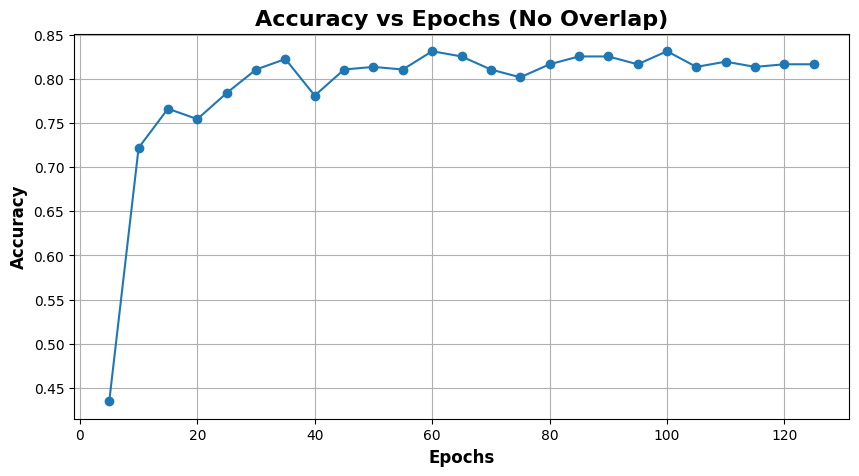

STEP 1: Discovering data files
  Found 72 file(s) in '/kaggle/input/datasets/rifattanbhir/emg-dataset'

STEP 2: Loading raw data  [done once]
  Raw data shape: (864000, 9)

STEP 3: Loading pretrained Mantis-8M  [done once]
  Device: cuda

#################################################################
# Run 1/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=5
#################################################################
Step size: 512

  [Segmenting] segment_length=512, overlap=0 → step_size=512
  Segments: (1687, 8, 512)  Labels: (1687,)
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=5  lr=2.00e-04


Epoch 4: Train Loss 1.5519: 100%|██████████| 5/5 [00:00<00:00, 50.26it/s]


  ✓ Accuracy: 0.4497

#################################################################
# Run 2/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=10
#################################################################
  [Cache hit]  segment_length=512, overlap=0 — reusing segments
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=10  lr=2.00e-04


Epoch 9: Train Loss 1.0477: 100%|██████████| 10/10 [00:00<00:00, 50.95it/s]


  ✓ Accuracy: 0.7249

#################################################################
# Run 3/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=15
#################################################################
  [Cache hit]  segment_length=512, overlap=0 — reusing segments
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=15  lr=2.00e-04


...

  ✓ Accuracy: 0.8521

#################################################################
# Run 24/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=120
#################################################################
  [Cache hit]  segment_length=512, overlap=0 — reusing segments
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=120  lr=2.00e-04


Epoch 119: Train Loss 0.2780: 100%|██████████| 120/120 [00:02<00:00, 51.93it/s]


  ✓ Accuracy: 0.8669

#################################################################
# Run 25/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=125
#################################################################
  [Cache hit]  segment_length=512, overlap=0 — reusing segments
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=125  lr=2.00e-04


Epoch 124: Train Loss 0.2715: 100%|██████████| 125/125 [00:02<00:00, 52.12it/s]


  ✓ Accuracy: 0.8462

ACCURACY SUMMARY
   test_size   seg_len   overlap          lr   epochs    accuracy
  --------------------------------------------------------------
        0.20       512         0    2.00e-04        5      0.4497
        0.20       512         0    2.00e-04       10      0.7249
        0.20       512         0    2.00e-04       15      0.7722
        0.20       512         0    2.00e-04       20      0.7929
        0.20       512         0    2.00e-04       25      0.7840
        0.20       512         0    2.00e-04       30      0.8343
        0.20       512         0    2.00e-04       35      0.8166
        0.20       512         0    2.00e-04       40      0.8402
        0.20       512         0    2.00e-04       45      0.8432
        0.20       512         0    2.00e-04       50      0.8314
        0.20       512         0    2.00e-04       55      0.8580
        0.20       512         0    2.00e-04       60      0.8343
        0.20       512         0    2.

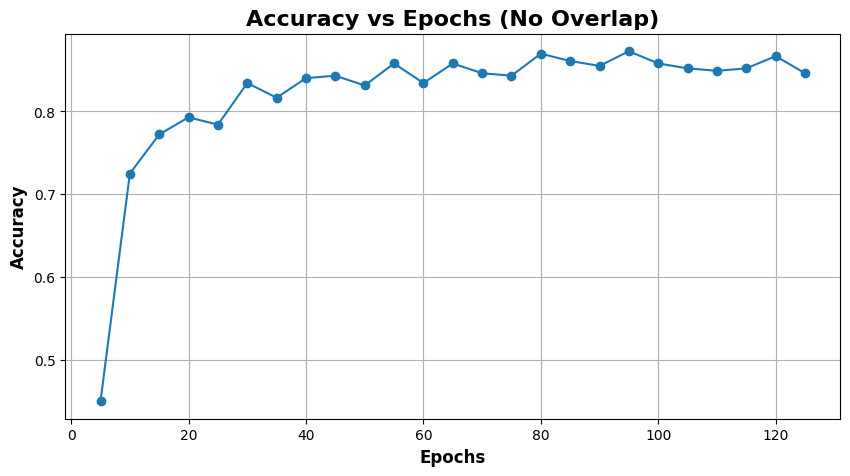

STEP 1: Discovering data files
  Found 72 file(s) in '/kaggle/input/datasets/rifattanbhir/emg-dataset'

STEP 2: Loading raw data  [done once]
  Raw data shape: (864000, 9)

STEP 3: Loading pretrained Mantis-8M  [done once]
  Device: cuda

#################################################################
# Run 1/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=5
#################################################################
Step size: 512

  [Segmenting] segment_length=512, overlap=0 → step_size=512
  Segments: (1687, 8, 512)  Labels: (1687,)
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=5  lr=2.00e-04


Epoch 4: Train Loss 1.5530: 100%|██████████| 5/5 [00:00<00:00, 48.45it/s]


  ✓ Accuracy: 0.4379

#################################################################
# Run 2/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=10
#################################################################
  [Cache hit]  segment_length=512, overlap=0 — reusing segments
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=10  lr=2.00e-04


Epoch 9: Train Loss 1.0610: 100%|██████████| 10/10 [00:00<00:00, 48.40it/s]


  ✓ Accuracy: 0.6953

#################################################################
# Run 3/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=15
#################################################################
  [Cache hit]  segment_length=512, overlap=0 — reusing segments
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=15  lr=2.00e-04


...

  ✓ Accuracy: 0.8432

#################################################################
# Run 24/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=120
#################################################################
  [Cache hit]  segment_length=512, overlap=0 — reusing segments
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=120  lr=2.00e-04


Epoch 119: Train Loss 0.2661: 100%|██████████| 120/120 [00:02<00:00, 46.46it/s]


  ✓ Accuracy: 0.8373

#################################################################
# Run 25/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=125
#################################################################
  [Cache hit]  segment_length=512, overlap=0 — reusing segments
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=125  lr=2.00e-04


Epoch 124: Train Loss 0.2542: 100%|██████████| 125/125 [00:02<00:00, 52.74it/s]


  ✓ Accuracy: 0.8343

ACCURACY SUMMARY
   test_size   seg_len   overlap          lr   epochs    accuracy
  --------------------------------------------------------------
        0.20       512         0    2.00e-04        5      0.4379
        0.20       512         0    2.00e-04       10      0.6953
        0.20       512         0    2.00e-04       15      0.7840
        0.20       512         0    2.00e-04       20      0.7840
        0.20       512         0    2.00e-04       25      0.8195
        0.20       512         0    2.00e-04       30      0.8225
        0.20       512         0    2.00e-04       35      0.8343
        0.20       512         0    2.00e-04       40      0.8136
        0.20       512         0    2.00e-04       45      0.8314
        0.20       512         0    2.00e-04       50      0.8343
        0.20       512         0    2.00e-04       55      0.8195
        0.20       512         0    2.00e-04       60      0.8343
        0.20       512         0    2.

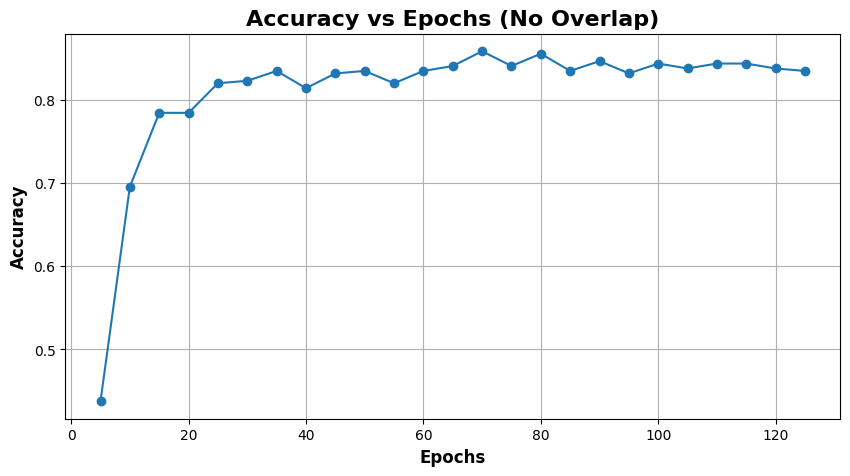

STEP 1: Discovering data files
  Found 72 file(s) in '/kaggle/input/datasets/rifattanbhir/emg-dataset'

STEP 2: Loading raw data  [done once]
  Raw data shape: (864000, 9)

STEP 3: Loading pretrained Mantis-8M  [done once]
  Device: cuda

#################################################################
# Run 1/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=5
#################################################################
Step size: 512

  [Segmenting] segment_length=512, overlap=0 → step_size=512
  Segments: (1687, 8, 512)  Labels: (1687,)
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=5  lr=2.00e-04


Epoch 4: Train Loss 1.5120: 100%|██████████| 5/5 [00:00<00:00, 48.40it/s]


  ✓ Accuracy: 0.5089

#################################################################
# Run 2/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=10
#################################################################
  [Cache hit]  segment_length=512, overlap=0 — reusing segments
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=10  lr=2.00e-04


Epoch 9: Train Loss 1.0560: 100%|██████████| 10/10 [00:00<00:00, 50.85it/s]


  ✓ Accuracy: 0.7396

#################################################################
# Run 3/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=15
#################################################################
  [Cache hit]  segment_length=512, overlap=0 — reusing segments
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=15  lr=2.00e-04


...

  ✓ Accuracy: 0.8432

#################################################################
# Run 24/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=120
#################################################################
  [Cache hit]  segment_length=512, overlap=0 — reusing segments
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=120  lr=2.00e-04


Epoch 119: Train Loss 0.2723: 100%|██████████| 120/120 [00:02<00:00, 51.65it/s]


  ✓ Accuracy: 0.8462

#################################################################
# Run 25/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=125
#################################################################
  [Cache hit]  segment_length=512, overlap=0 — reusing segments
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=125  lr=2.00e-04


Epoch 124: Train Loss 0.2784: 100%|██████████| 125/125 [00:02<00:00, 47.56it/s]


  ✓ Accuracy: 0.8491

ACCURACY SUMMARY
   test_size   seg_len   overlap          lr   epochs    accuracy
  --------------------------------------------------------------
        0.20       512         0    2.00e-04        5      0.5089
        0.20       512         0    2.00e-04       10      0.7396
        0.20       512         0    2.00e-04       15      0.7544
        0.20       512         0    2.00e-04       20      0.8107
        0.20       512         0    2.00e-04       25      0.8018
        0.20       512         0    2.00e-04       30      0.8254
        0.20       512         0    2.00e-04       35      0.8343
        0.20       512         0    2.00e-04       40      0.8077
        0.20       512         0    2.00e-04       45      0.8254
        0.20       512         0    2.00e-04       50      0.8254
        0.20       512         0    2.00e-04       55      0.8432
        0.20       512         0    2.00e-04       60      0.8521
        0.20       512         0    2.

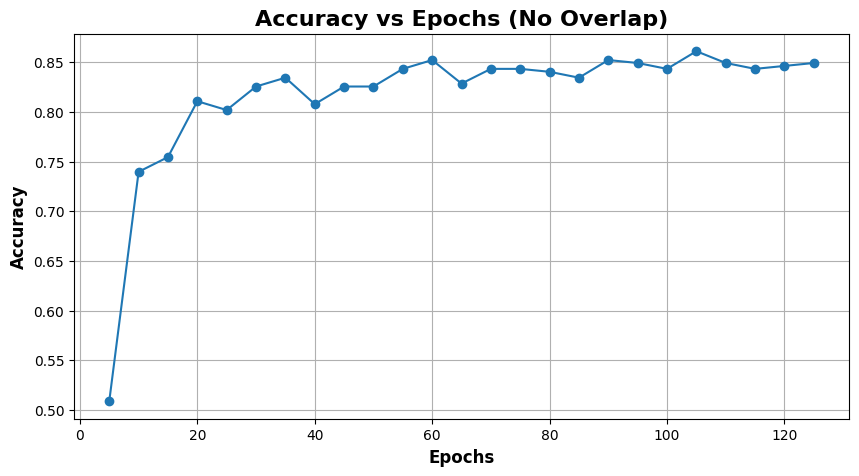

STEP 1: Discovering data files
  Found 72 file(s) in '/kaggle/input/datasets/rifattanbhir/emg-dataset'

STEP 2: Loading raw data  [done once]
  Raw data shape: (864000, 9)

STEP 3: Loading pretrained Mantis-8M  [done once]
  Device: cuda

#################################################################
# Run 1/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=5
#################################################################
Step size: 512

  [Segmenting] segment_length=512, overlap=0 → step_size=512
  Segments: (1687, 8, 512)  Labels: (1687,)
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=5  lr=2.00e-04


Epoch 4: Train Loss 1.6301: 100%|██████████| 5/5 [00:00<00:00, 50.37it/s]


  ✓ Accuracy: 0.4024

#################################################################
# Run 2/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=10
#################################################################
  [Cache hit]  segment_length=512, overlap=0 — reusing segments
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=10  lr=2.00e-04


Epoch 9: Train Loss 1.0654: 100%|██████████| 10/10 [00:00<00:00, 49.09it/s]


  ✓ Accuracy: 0.7130

#################################################################
# Run 3/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=15
#################################################################
  [Cache hit]  segment_length=512, overlap=0 — reusing segments
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=15  lr=2.00e-04


...

  ✓ Accuracy: 0.8462

#################################################################
# Run 24/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=120
#################################################################
  [Cache hit]  segment_length=512, overlap=0 — reusing segments
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=120  lr=2.00e-04


Epoch 119: Train Loss 0.2703: 100%|██████████| 120/120 [00:02<00:00, 45.92it/s]


  ✓ Accuracy: 0.8254

#################################################################
# Run 25/25 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=125
#################################################################
  [Cache hit]  segment_length=512, overlap=0 — reusing segments
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='head'  epochs=125  lr=2.00e-04


Epoch 124: Train Loss 0.2613: 100%|██████████| 125/125 [00:02<00:00, 51.61it/s]


  ✓ Accuracy: 0.8225

ACCURACY SUMMARY
   test_size   seg_len   overlap          lr   epochs    accuracy
  --------------------------------------------------------------
        0.20       512         0    2.00e-04        5      0.4024
        0.20       512         0    2.00e-04       10      0.7130
        0.20       512         0    2.00e-04       15      0.7692
        0.20       512         0    2.00e-04       20      0.7811
        0.20       512         0    2.00e-04       25      0.8136
        0.20       512         0    2.00e-04       30      0.8077
        0.20       512         0    2.00e-04       35      0.8254
        0.20       512         0    2.00e-04       40      0.8373
        0.20       512         0    2.00e-04       45      0.8314
        0.20       512         0    2.00e-04       50      0.8166
        0.20       512         0    2.00e-04       55      0.8462
        0.20       512         0    2.00e-04       60      0.8314
        0.20       512         0    2.

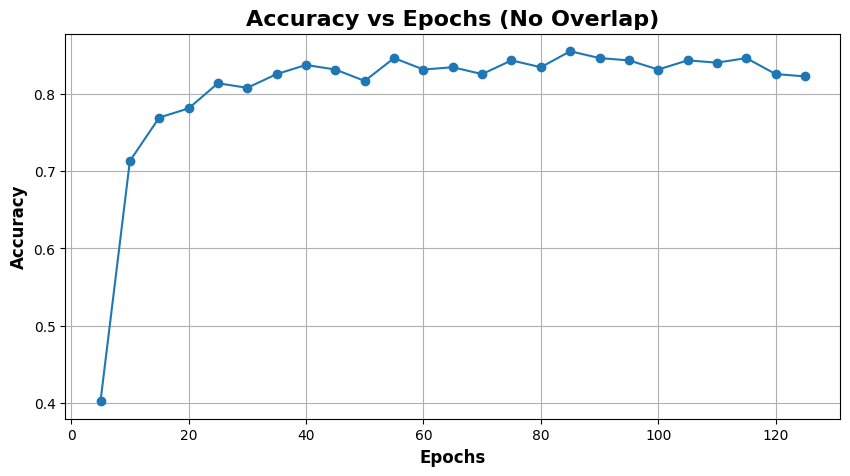

In [ ]:
import matplotlib.pyplot as plt
# if __name__ == "__main__":
for seed in seedList:
    results = run_pipeline(
        data_dir      = "/kaggle/input/datasets/rifattanbhir/emg-dataset",
        test_size     = 0.2,
        tuning_type   = "head",
        segment_length= 512,
        overlap       = 0,
        learning_rate = 2e-4,
        num_epochs    = list([i*5 for i in range(1, 26)]),
        random_state  = seed,
    )
    
    epoch_accuracy = [(epochs, acc) for (ts, seg_len, ovlp, lr, epochs), acc in results["accuracy_summary"].items()]

    # Or as two separate lists, useful for plotting
    epoch_list    = [epochs for (_, _, _, _, epochs), _ in results["accuracy_summary"].items()]
    accuracy_list = [acc    for _, acc               in results["accuracy_summary"].items()]
    np.save(f'no_overlap_accuracy_seed{seed}.npy', accuracy_list)
    np.save(f'no_overlap_epoch_seed{seed}.npy', epoch_list)
    
    # Plotting
    plt.figure(figsize=(10,5))
    plt.plot(epoch_list, accuracy_list, marker='o')
    plt.grid('True')
    plt.xlabel('Epochs', fontsize=12, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
    plt.title('Accuracy vs Epochs (No Overlap)', fontsize=16, fontweight='bold')
    plt.savefig('accuracy_plot_no_overlap.tif', dpi=300)
    plt.show()
    # accuracy_list


In [ ]:
# if __name__ == "__main__":
for seed in seedList:
 
    results = run_pipeline(
        data_dir      = "/kaggle/input/datasets/rifattanbhir/emg-dataset",
        test_size     = [0.2, 0.3, 0.4],
        tuning_type   = "head",
        segment_length= [200, 300, 400, 512],
        overlap       = 0,
        learning_rate = 2e-4,
        num_epochs    = 90,
        random_state  = seed,
    )
    
    # Build a DataFrame from accuracy_summary
    rows = []
    for (ts, seg_len, ovlp, lr, epochs), acc in results["accuracy_summary"].items():
        rows.append({
            "test_size": ts,
            "seg_len":   seg_len,
            "overlap":   ovlp,
            "lr":        lr,
            "epochs":    epochs,
            "accuracy":  acc
        })
    
    df = pd.DataFrame(rows)
    
    # Add summary rows
    summary = pd.DataFrame([
        {"test_size": "MEAN",  "accuracy": results["mean_accuracy"]},
        {"test_size": "BEST",  "seg_len": results["best"]["combo"][1],  "accuracy": results["best"]["accuracy"]},
        {"test_size": "WORST", "seg_len": results["worst"]["combo"][1], "accuracy": results["worst"]["accuracy"]},
    ])
    
    df_final = pd.concat([df, summary], ignore_index=True)
    df_final.to_csv(f"'head'_no_overlap_accuracy_summary_seed{seed}.csv", index=False)


STEP 1: Discovering data files
  Found 72 file(s) in '/kaggle/input/datasets/rifattanbhir/emg-dataset'

STEP 2: Loading raw data  [done once]
  Raw data shape: (864000, 9)

STEP 3: Loading pretrained Mantis-8M  [done once]
  Device: cuda


config.json:   0%|          | 0.00/335 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/32.5M [00:00<?, ?B/s]


#################################################################
# Run 1/12 │ test_size=0.2  seg_len=200  overlap=0  lr=2.00e-04  epochs=90
#################################################################
Step size: 200

  [Segmenting] segment_length=200, overlap=0 → step_size=200
  Segments: (4320, 8, 512)  Labels: (4320,)
  Split → Train: (3456, 8, 512)  Test: (864, 8, 512)
  Fine-tuning  type='head'  epochs=90  lr=2.00e-04


Epoch 89: Train Loss 0.3343: 100%|██████████| 90/90 [00:04<00:00, 19.71it/s]


...

  ✓ Accuracy: 0.8491

#################################################################
# Run 11/12 │ test_size=0.3  seg_len=512  overlap=0  lr=2.00e-04  epochs=90
#################################################################
  [Cache hit]  segment_length=512, overlap=0 — reusing segments
  Split → Train: (1180, 8, 512)  Test: (507, 8, 512)
  Fine-tuning  type='head'  epochs=90  lr=2.00e-04


Epoch 89: Train Loss 0.3551: 100%|██████████| 90/90 [00:01<00:00, 60.01it/s]


  ✓ Accuracy: 0.8462

#################################################################
# Run 12/12 │ test_size=0.4  seg_len=512  overlap=0  lr=2.00e-04  epochs=90
#################################################################
  [Cache hit]  segment_length=512, overlap=0 — reusing segments
  Split → Train: (1012, 8, 512)  Test: (675, 8, 512)
  Fine-tuning  type='head'  epochs=90  lr=2.00e-04


Epoch 89: Train Loss 0.3760: 100%|██████████| 90/90 [00:01<00:00, 60.54it/s]


  ✓ Accuracy: 0.8296

ACCURACY SUMMARY
   test_size   seg_len   overlap          lr   epochs    accuracy
  --------------------------------------------------------------
        0.20       200         0    2.00e-04       90      0.8333
        0.30       200         0    2.00e-04       90      0.8256
        0.40       200         0    2.00e-04       90      0.8293
        0.20       300         0    2.00e-04       90      0.8594
        0.30       300         0    2.00e-04       90      0.8461
        0.40       300         0    2.00e-04       90      0.8377
        0.20       400         0    2.00e-04       90      0.7616
        0.30       400         0    2.00e-04       90      0.7840
        0.40       400         0    2.00e-04       90      0.8067
        0.20       512         0    2.00e-04       90      0.8491
        0.30       512         0    2.00e-04       90      0.8462
        0.40       512         0    2.00e-04       90      0.8296
  ------------------------------------

In [ ]:
# if __name__ == "__main__":
for seed in seedList:
 
    results = run_pipeline(
        data_dir      = "/kaggle/input/datasets/rifattanbhir/emg-dataset",
        test_size     = 0.2,
        tuning_type   = "full",
        segment_length= 512,
        overlap       = 0,
        learning_rate = 2e-4,
        num_epochs    = 90,
        random_state  = seed,
    )

    # Build a DataFrame from accuracy_summary
    rows = []
    for (ts, seg_len, ovlp, lr, epochs), acc in results["accuracy_summary"].items():
        rows.append({
            "test_size": ts,
            "seg_len":   seg_len,
            "overlap":   ovlp,
            "lr":        lr,
            "epochs":    epochs,
            "accuracy":  acc
        })
    
    df = pd.DataFrame(rows)
    
    # Add summary rows
    summary = pd.DataFrame([
        {"test_size": "MEAN",  "accuracy": results["mean_accuracy"]},
        {"test_size": "BEST",  "seg_len": results["best"]["combo"][1],  "accuracy": results["best"]["accuracy"]},
        {"test_size": "WORST", "seg_len": results["worst"]["combo"][1], "accuracy": results["worst"]["accuracy"]},
    ])
    
    df_final = pd.concat([df, summary], ignore_index=True)
    df_final.to_csv(f"'full'_no_overlap_accuracy_summary_seed{seed}.csv", index=False)


STEP 1: Discovering data files
  Found 72 file(s) in '/kaggle/input/datasets/rifattanbhir/emg-dataset'

STEP 2: Loading raw data  [done once]
  Raw data shape: (864000, 9)

STEP 3: Loading pretrained Mantis-8M  [done once]
  Device: cuda


config.json:   0%|          | 0.00/335 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/32.5M [00:00<?, ?B/s]


#################################################################
# Run 1/1 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=90
#################################################################
Step size: 512

  [Segmenting] segment_length=512, overlap=0 → step_size=512
  Segments: (1687, 8, 512)  Labels: (1687,)
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='full'  epochs=90  lr=2.00e-04


Epoch 89: Train Loss 0.0109: 100%|██████████| 90/90 [13:53<00:00,  9.27s/it]


...

  ✓ Accuracy: 0.8580

ACCURACY SUMMARY
  test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=90  accuracy=0.8580
STEP 1: Discovering data files
  Found 72 file(s) in '/kaggle/input/datasets/rifattanbhir/emg-dataset'

STEP 2: Loading raw data  [done once]
  Raw data shape: (864000, 9)

STEP 3: Loading pretrained Mantis-8M  [done once]
  Device: cuda

#################################################################
# Run 1/1 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=90
#################################################################
Step size: 512

  [Segmenting] segment_length=512, overlap=0 → step_size=512
  Segments: (1687, 8, 512)  Labels: (1687,)
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='full'  epochs=90  lr=2.00e-04


Epoch 89: Train Loss 0.0088: 100%|██████████| 90/90 [14:06<00:00,  9.40s/it]


  ✓ Accuracy: 0.8669

ACCURACY SUMMARY
  test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=90  accuracy=0.8669
STEP 1: Discovering data files
  Found 72 file(s) in '/kaggle/input/datasets/rifattanbhir/emg-dataset'

STEP 2: Loading raw data  [done once]
  Raw data shape: (864000, 9)

STEP 3: Loading pretrained Mantis-8M  [done once]
  Device: cuda

#################################################################
# Run 1/1 │ test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=90
#################################################################
Step size: 512

  [Segmenting] segment_length=512, overlap=0 → step_size=512
  Segments: (1687, 8, 512)  Labels: (1687,)
  Split → Train: (1349, 8, 512)  Test: (338, 8, 512)
  Fine-tuning  type='full'  epochs=90  lr=2.00e-04


Epoch 89: Train Loss 0.0108: 100%|██████████| 90/90 [14:05<00:00,  9.40s/it]


  ✓ Accuracy: 0.8373

ACCURACY SUMMARY
  test_size=0.2  seg_len=512  overlap=0  lr=2.00e-04  epochs=90  accuracy=0.8373


In [ ]:
if __name__ == "__main__":
 
    # ── Single run ──────────────────────────────────────────────────────────
    # results = run_pipeline(
    #     data_dir      = "/kaggle/input/datasets/rifattanbhir/emg-dataset",
    #     test_size     = 0.2,
    #     tuning_type   = "head",
    #     segment_length= 512,
    #     step_size     = 200,
    #     learning_rate = 2e-4,
    #     num_epochs    = 100,
    # )
 
    # ── Multi-value sweep ────────────────────────────────────────────────────
    results = run_pipeline(
        data_dir       = "/kaggle/input/datasets/rifattanbhir/emg-dataset",
        test_size      = [0.2, 0.3, 0.4],   # 4 values
        tuning_type    = "full",
        segment_length = [512],              # 4 values
        # step_size      = [100, 200],              # 2 values
        overlap        = 0,
        learning_rate  = 2e-4,            # 1 values  →  4×4×1 = 16 runs
        num_epochs     = 100,
    )
 
    print(f"\nBest  : {results['best']}")
    print(f"Worst : {results['worst']}")
    print(f"Mean  : {results['mean_accuracy']:.4f}")
 
    # Access a specific run's full details:
    # detail = results["all_results"][(0.2, 512, 200, 2e-4)]


In [ ]:
!zip -r folder.zip /kaggle/working/


updating: kaggle/working/ (stored 0%)
updating: kaggle/working/'full'_no_overlap_accuracy_summary_seed123.csv (deflated 43%)
updating: kaggle/working/'full'_no_overlap_accuracy_summary_seed5.csv (deflated 43%)
updating: kaggle/working/.virtual_documents/ (stored 0%)
updating: kaggle/working/.virtual_documents/__notebook_source__.ipynb (deflated 78%)
updating: kaggle/working/'full'_no_overlap_accuracy_summary_seed100.csv (deflated 43%)
updating: kaggle/working/'full'_no_overlap_accuracy_summary_seed42.csv (deflated 43%)
updating: kaggle/working/'full'_no_overlap_accuracy_summary_seed1.csv (deflated 43%)
  adding: kaggle/working/'full'_50%_overlap_accuracy_summary_seed1.csv (deflated 45%)
  adding: kaggle/working/'full'_50%_overlap_accuracy_summary_seed5.csv (deflated 45%)
  adding: kaggle/working/'full'_50%_overlap_accuracy_summary_seed123.csv (deflated 45%)
  adding: kaggle/working/'full'_50%_overlap_accuracy_summary_seed42.csv (deflated 45%)
  adding: kaggle/working/'full'_50%_overlap

In [ ]:
from IPython.display import FileLink
FileLink(r'folder.zip')


/kaggle/working/folder.zip

# With Processed Data

In [ ]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/sojanprajapati/emg-signal-for-gesture-recognition/EMG-data.csv")
df.head()


In [ ]:
df.drop(columns=['time','label'], inplace=True)
df = df[~df['class'].isin([0,7])] # Remove rows where 'class' is 0 or 7
df.head()


In [ ]:
if __name__ == "__main__":
 
    # ── Single run ──────────────────────────────────────────────────────────
    # results = run_pipeline(
    #     data_dir      = "/kaggle/input/datasets/rifattanbhir/emg-dataset",
    #     test_size     = 0.2,
    #     tuning_type   = "head",
    #     segment_length= 512,
    #     step_size     = 200,
    #     learning_rate = 2e-4,
    #     num_epochs    = 100,
    # )
 
    # ── Multi-value sweep ────────────────────────────────────────────────────
    results = run_pipeline(
        raw_data       = df,
        test_size      = [0.2, 0.3, 0.4],   # 4 values
        tuning_type    = "head",
        segment_length = [200, 300, 400, 512],              # 4 values
        # step_size      = [100, 200],              # 2 values
        overlap        = 0,
        learning_rate  = 2e-4,            # 1 values  →  4×4×1 = 16 runs
        num_epochs     = 100,
    )
 
    print(f"\nBest  : {results['best']}")
    print(f"Worst : {results['worst']}")
    print(f"Mean  : {results['mean_accuracy']:.4f}")
 
    # Access a specific run's full details:
    # detail = results["all_results"][(0.2, 512, 200, 2e-4)]
